# Présentation Board NUCLEO-F439ZI — Sprints 16–21

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Période** : mai–juin 2026

---

Ce notebook est un support de présentation interactif. Il affiche les figures générées par
`scripts/generate_presentation_plots.py` dans l'ordre pédagogique, avec commentaires.

**Avant d'exécuter** : lancer une fois le script de génération :
```bash
python scripts/generate_presentation_plots.py
```
Puis : `Kernel → Restart & Run All`

In [27]:
import subprocess
import os
from IPython.display import Image, display, Markdown

FIGURES_DIR = "../docs/figures/presentation_board"

# Générer les figures si elles n'existent pas encore
if not os.path.exists(os.path.join(FIGURES_DIR, "01_ram_budget.png")):
    print("Génération des figures...")
    result = subprocess.run(
        ["python", "../scripts/generate_presentation_plots.py", "--output", FIGURES_DIR],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("ERREUR:", result.stderr)
else:
    print(f"✅ Figures déjà présentes dans {FIGURES_DIR}/")

def fig(name, width=900):
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print(f"⚠️ Figure manquante : {path}")

✅ Figures déjà présentes dans ../docs/figures/presentation_board/


---
## 1. Vue d'ensemble — Timeline des Sprints 16–20

Le projet embarqué (Phase 2) couvre 5 sprints sur mai–juin 2026.  
- **Sprint 16** : mise en place toolchain ARM (arm-none-eabi-gcc, OpenOCD, CMake, Unity)
- **Sprint 17** : périphériques HAL (GPIO, UART printf, PWM), Renode CI
- **Sprint 18** : pipeline UART v2 + profiling DWT, expérience E18-01 sur carte
- **Sprint 19** : 3 modèles CL en C (Mahalanobis, EWC, TinyOL), protocole v3 avec métriques CL
- **Sprint 20** : finalisation EWC, poids TinyOL, Gap 2 formel

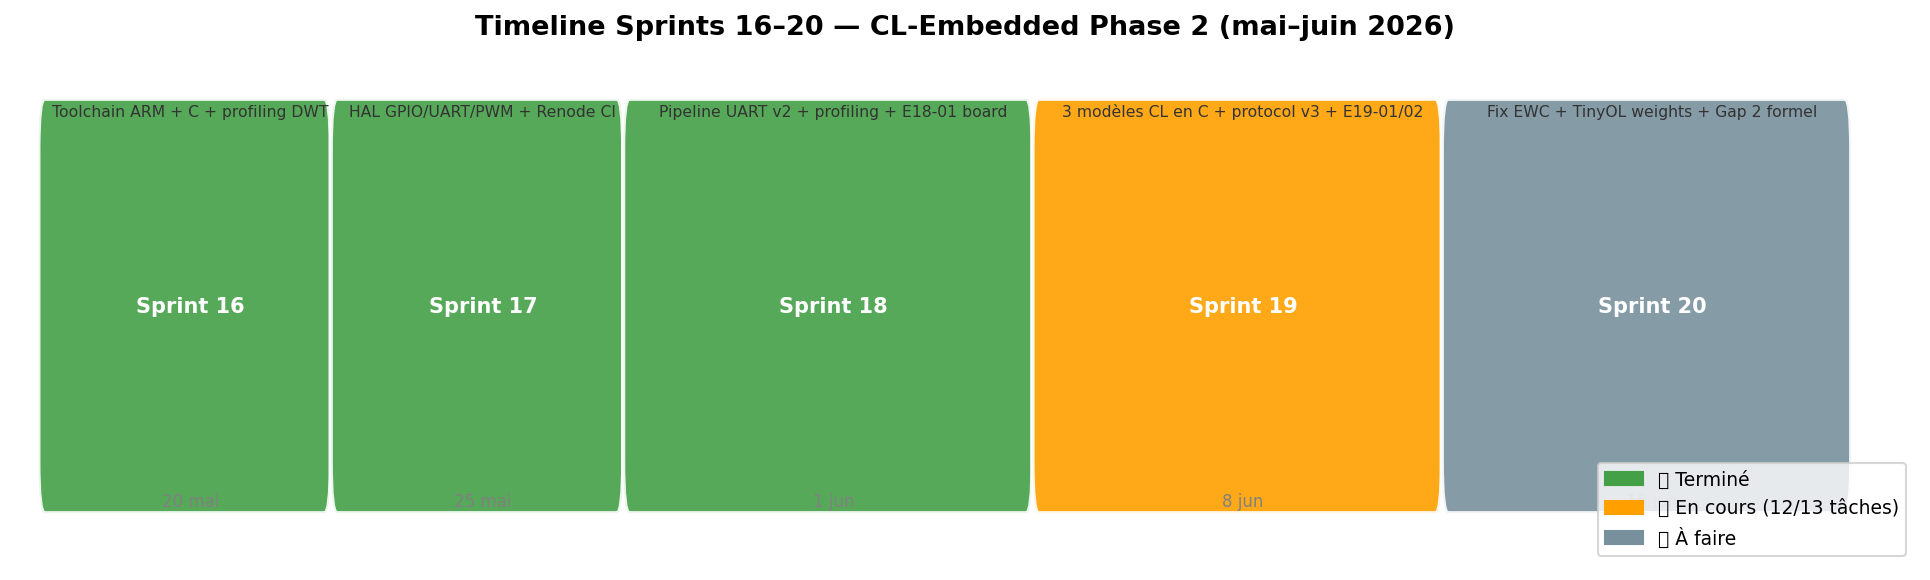

In [28]:
fig("07_sprint_timeline")

---
## 2. Architecture firmware — Comment le code contrôle la carte

Le PC envoie des trames UART via le ST-LINK VCP (`/dev/ttyACM0`, 115 200 baud).  
Le firmware reçoit dans `pipeline.c`, appelle le modèle sélectionné, et renvoie la réponse.

**Fichiers clés** :
- `main.c` : init 180 MHz, UART, DWT, boucle infinie → `pipeline_run()`
- `pipeline.c` : orchestrateur — décode trame, appelle modèle, encode réponse
- `ewc_head.c` : MLP 3 couches + régularisation EWC, ~9.7 Ko SRAM
- `tinyol.c` : autoencoder forward pass, poids en Flash
- `profiling.c` : latence DWT + RAM .bss via symboles linker

**Contrainte fondamentale** : zéro `malloc()` — tout est en stack local ou BSS statique.

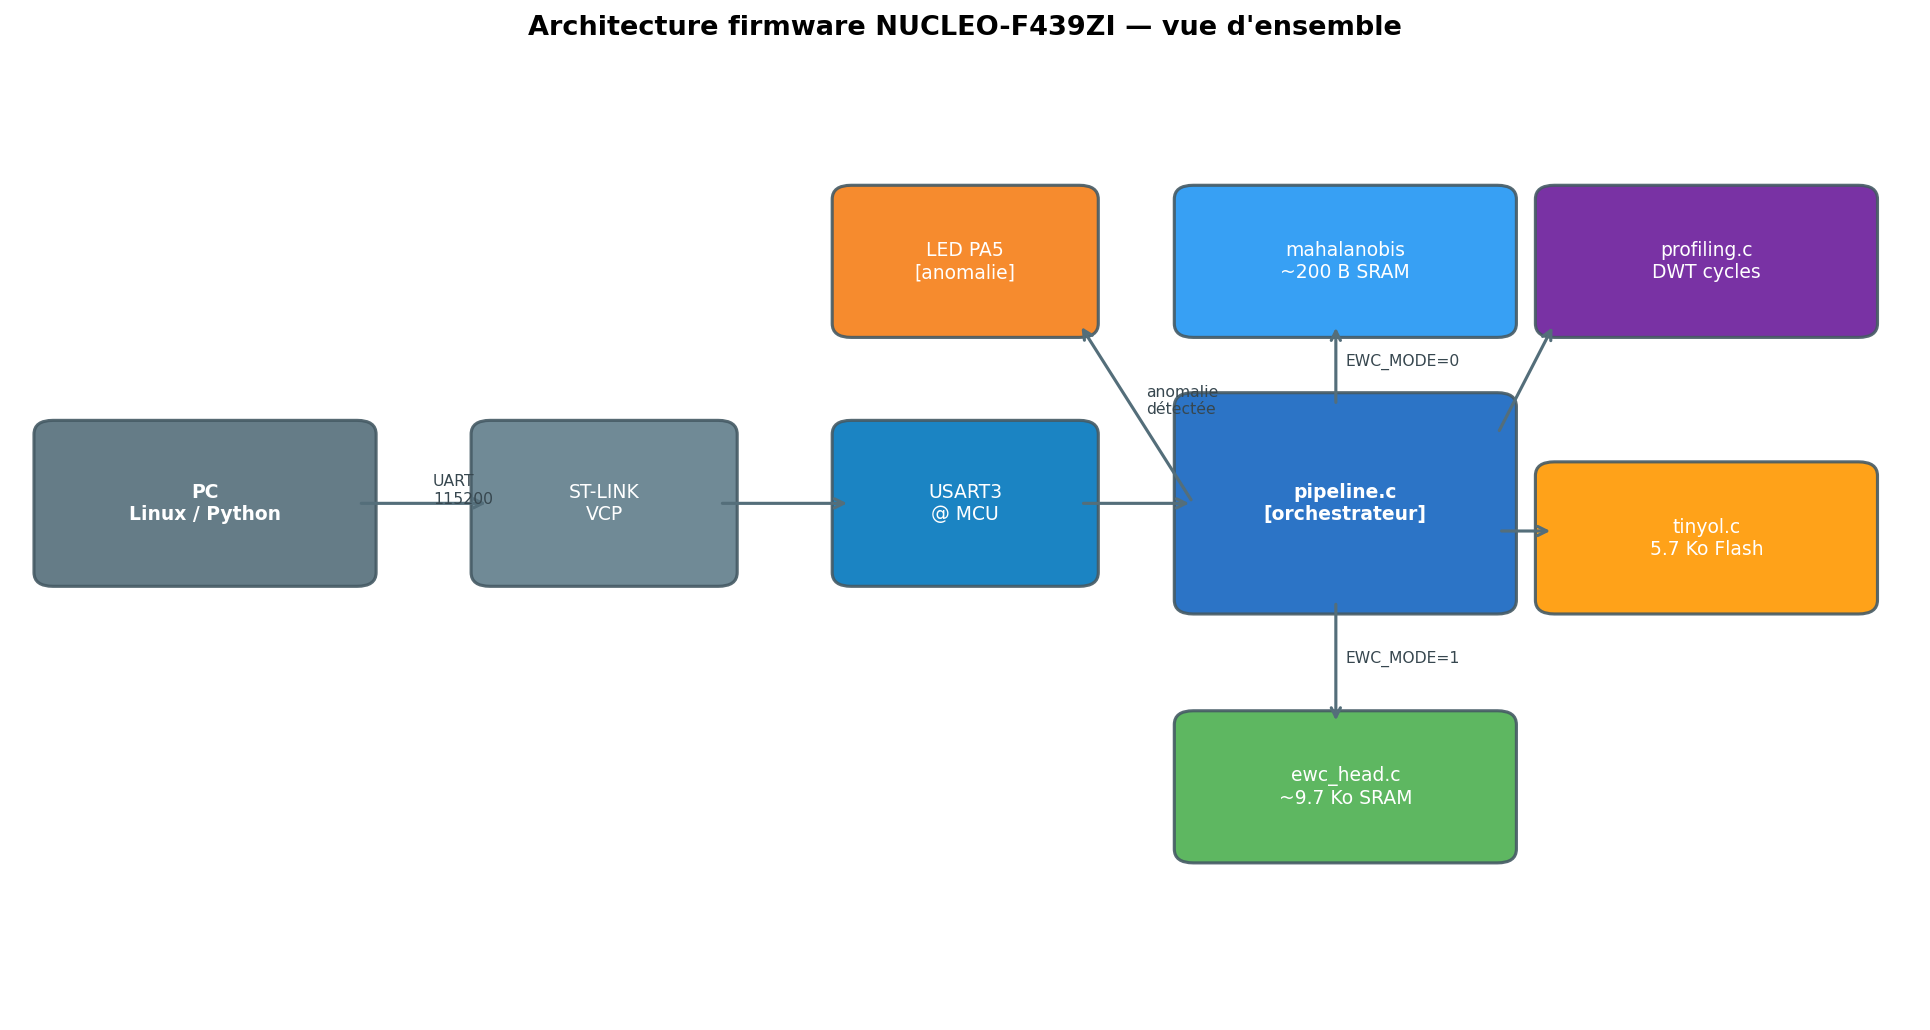

In [29]:
fig("08_firmware_architecture")

---
## 3. Protocole UART — Communication binaire PC ↔ Carte

Le protocole est **binaire little-endian** avec CRC8 (pas de texte ASCII).  
Taille de la trame request : **32 octets** pour 5 features.

**Évolution :**
- **v2 (Sprint 18)** : réponse 14 B — prediction, confiance, latence DWT, RAM .bss, throughput
- **v3 (Sprint 19)** : réponse 21 B — + accuracy online, AUROC, forgetting (métriques CL temps réel)

**Flags de contrôle** : `UPDATE` (apprendre), `CONSOLIDATE` (fin de tâche EWC), `RESET`, `EWC_MODE`

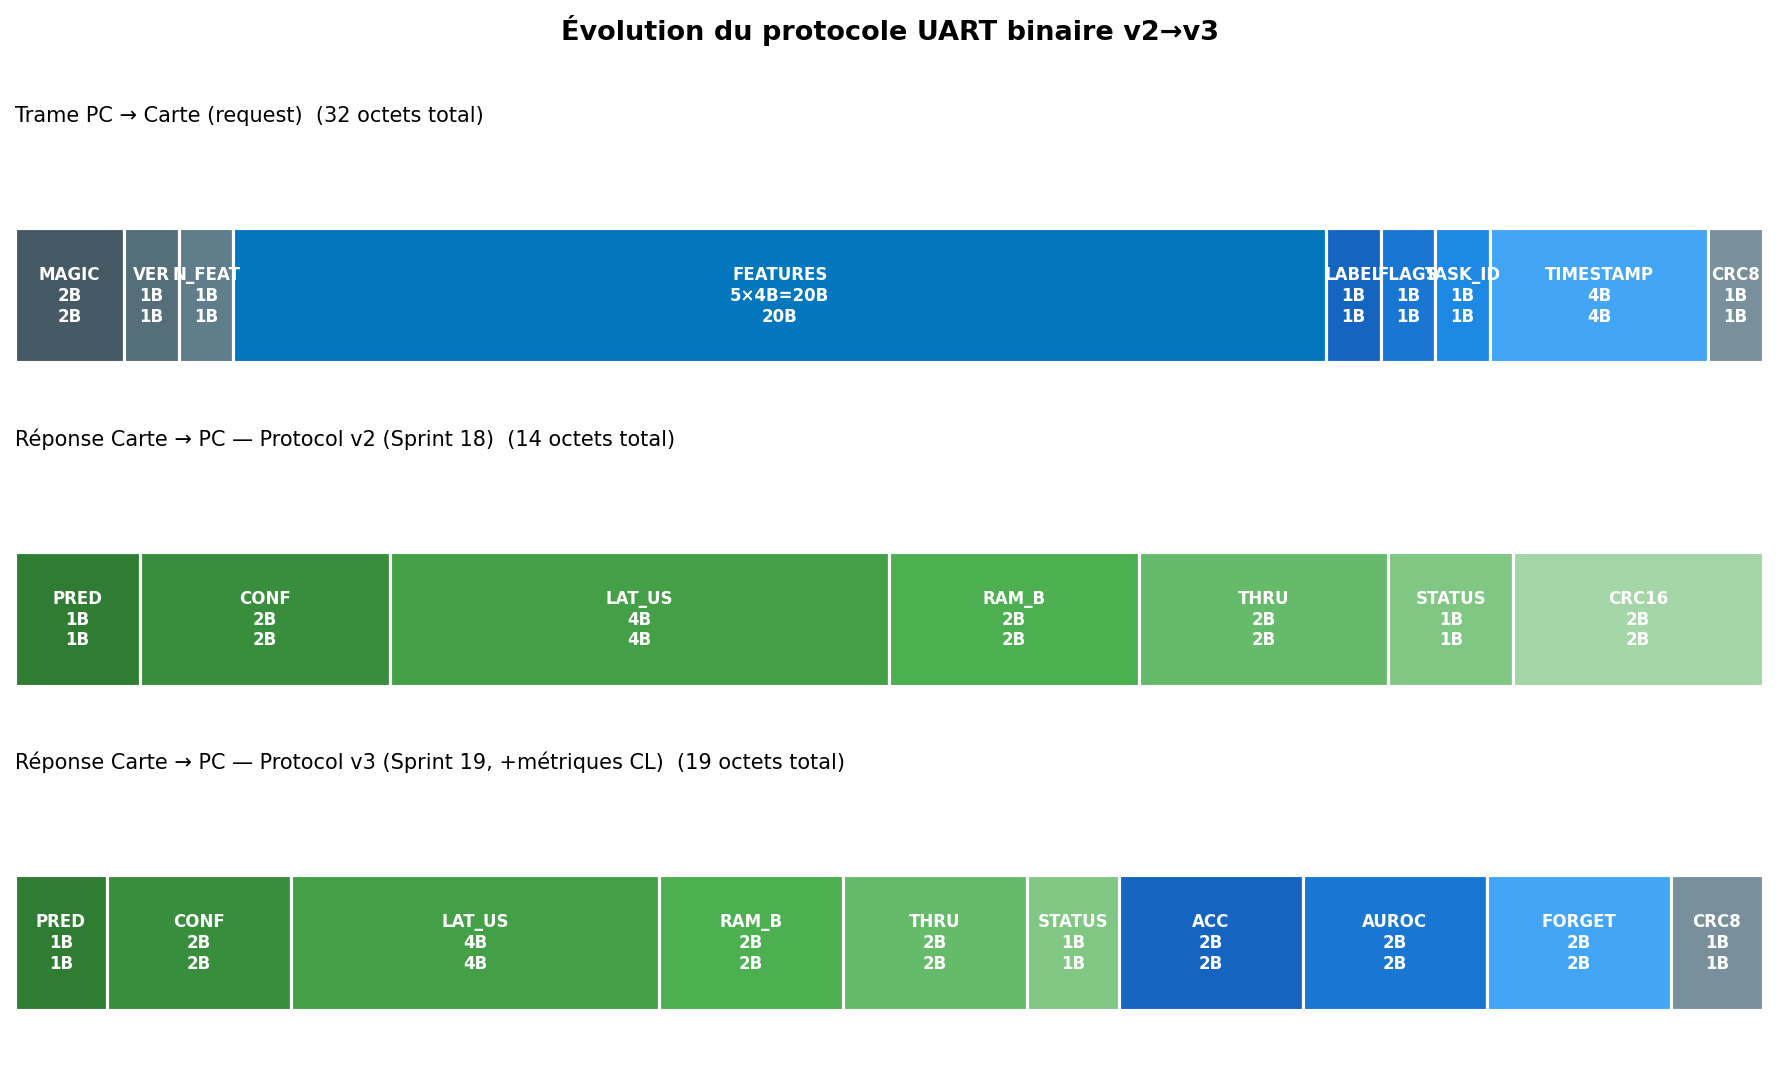

In [30]:
fig("09_uart_protocol")

---
## 4. Budget RAM — Empreinte mémoire par modèle vs limite Gap 2

**Gap 2** : être le premier travail à démontrer du Continual Learning avec **< 64 Ko SRAM** et des chiffres mesurés précisément sur hardware réel.

La NUCLEO-F439ZI dispose de 256 Ko, mais tout le code est conçu pour tenir dans 64 Ko (portabilité vers STM32N6).

| Modèle | RAM .bss | Marge / 64 Ko |
|--------|---------|---------------|
| Mahalanobis | 200 B | ×328 |
| EWC Head MLP | 9.7 Ko | ×6.8 |
| TinyOL (SRAM) | 400 B | ×164 |
| HDC | 28 Ko | ×2.3 |
| **3 modèles simultanés** | **~11 Ko** | **×5.8** |

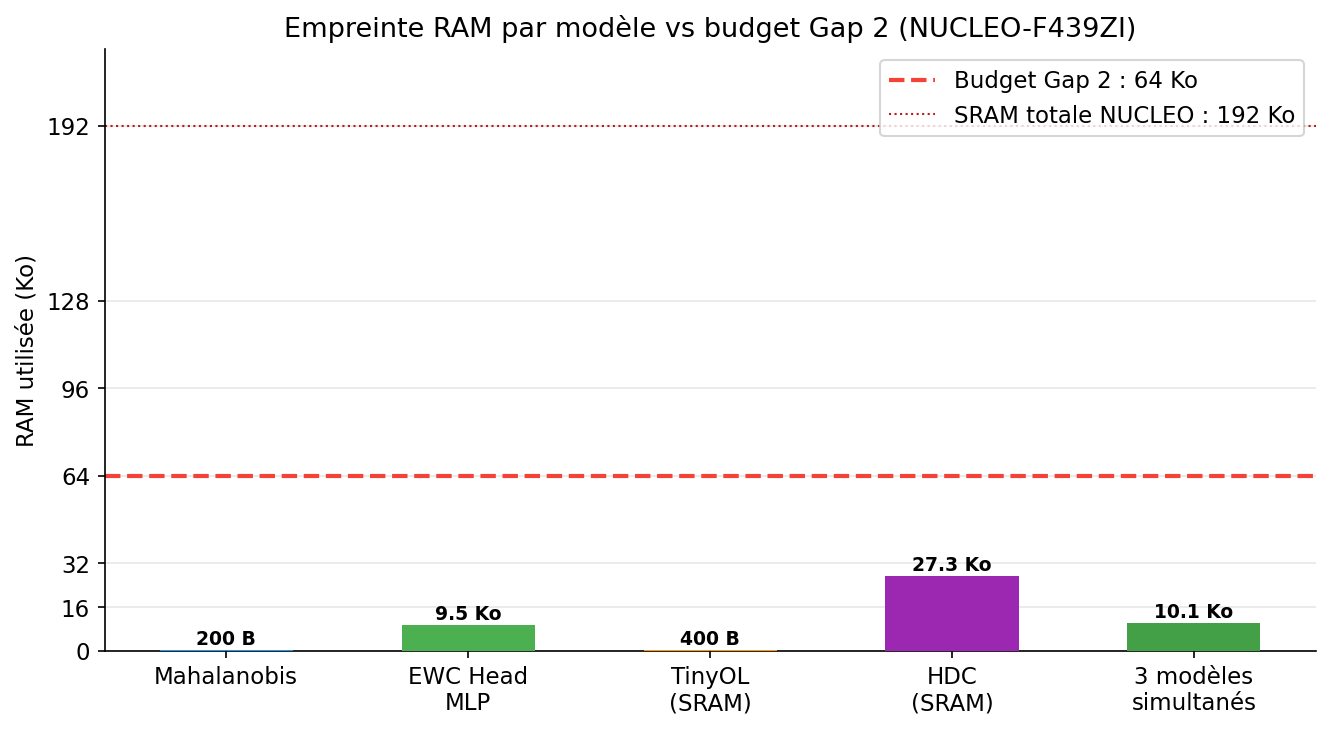

In [31]:
fig("01_ram_budget")

---
## 5. Répartition mémoire — Flash vs SRAM par modèle

Distinction importante entre **Flash** (`.rodata` — poids constants entraînés offline, ne consomment pas de SRAM)
et **SRAM** (`.bss` — poids entraînables mis à jour en ligne).

**TinyOL** : les poids du backbone (5.7 Ko) sont en Flash — seules les activations temporaires (stack)
et la tête OtO (40 B) sont en SRAM.  
**EWC** : tous les poids (weights + Fisher + star_weights) sont en SRAM car modifiés à chaque sample.

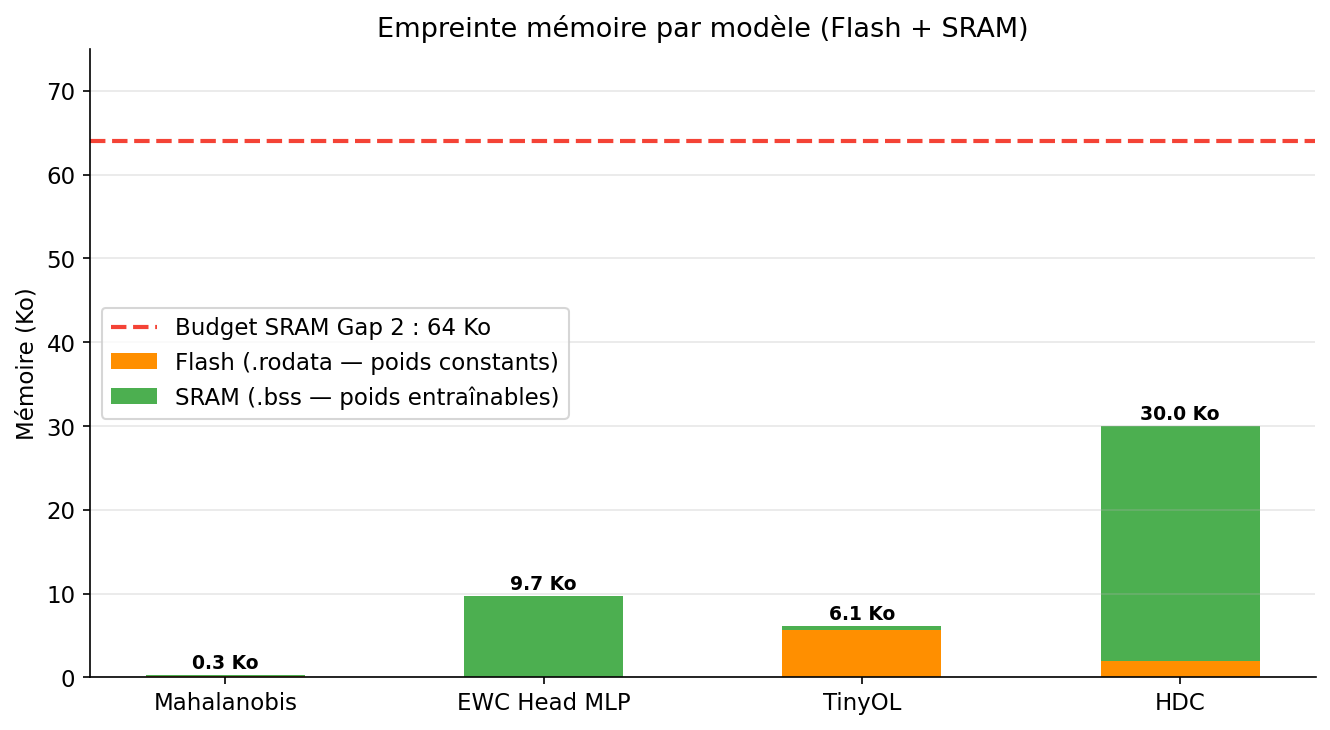

In [32]:
fig("06_memory_breakdown")

---
## 6. Conformité Gap 2 — Tableau de validation

Le Gap 2 est satisfait si **RAM < 64 Ko ET latence < 100 ms** pour chaque modèle,
avec des mesures hardware précises (pas d'estimations).

Les mesures sont faites via :
- **RAM** : `parse_map_file.py` sur le `.map` linker (symboles `.bss`)
- **Latence** : compteur DWT (Data Watchpoint and Trace) hardware @ 180 MHz, précision 5.5 ns

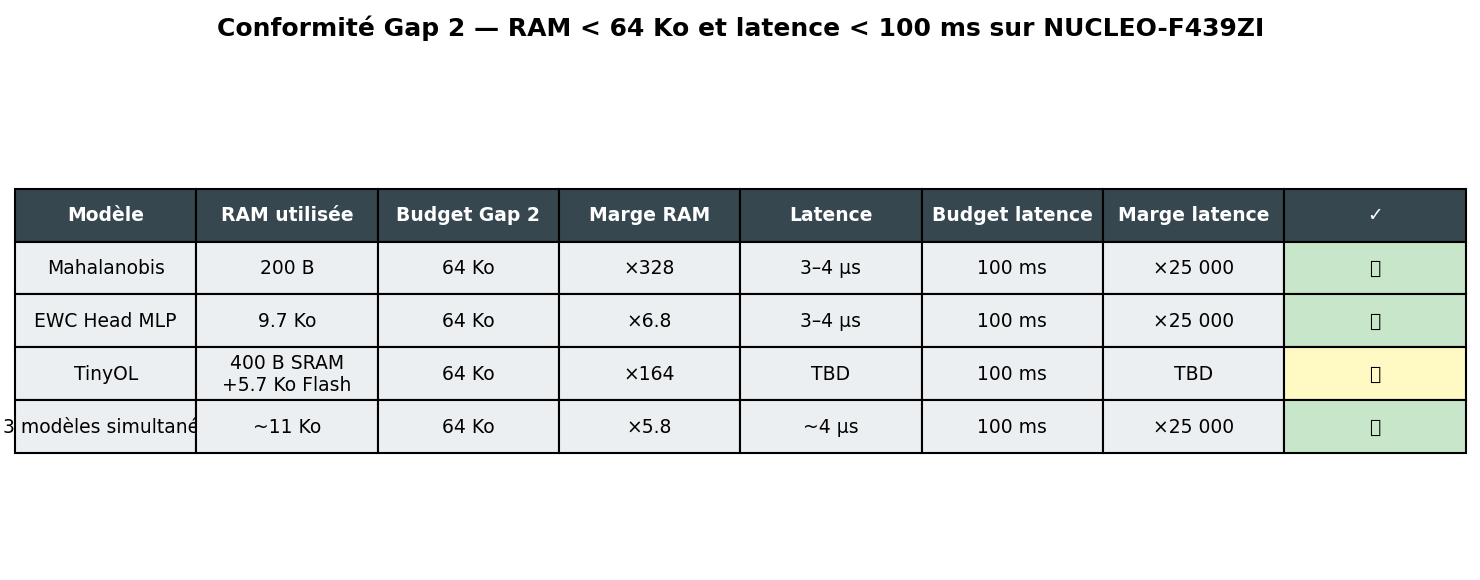

In [33]:
fig("11_gap2_compliance")

---
## 7. Latence d'inférence — Résultats mesurés

La latence de **3–4 µs** est rendue possible par le **Cortex-M4 avec FPU hardware** (virgule flottante en 1 cycle).
Les opérations matricielles FP32 à cette échelle (5×32, 32×16) s'exécutent très efficacement.

La marge de ×25 000 par rapport au budget de 100 ms signifie que la carte pourrait théoriquement
traiter des modèles **25 000× plus complexes** et rester dans le budget Gap 2.

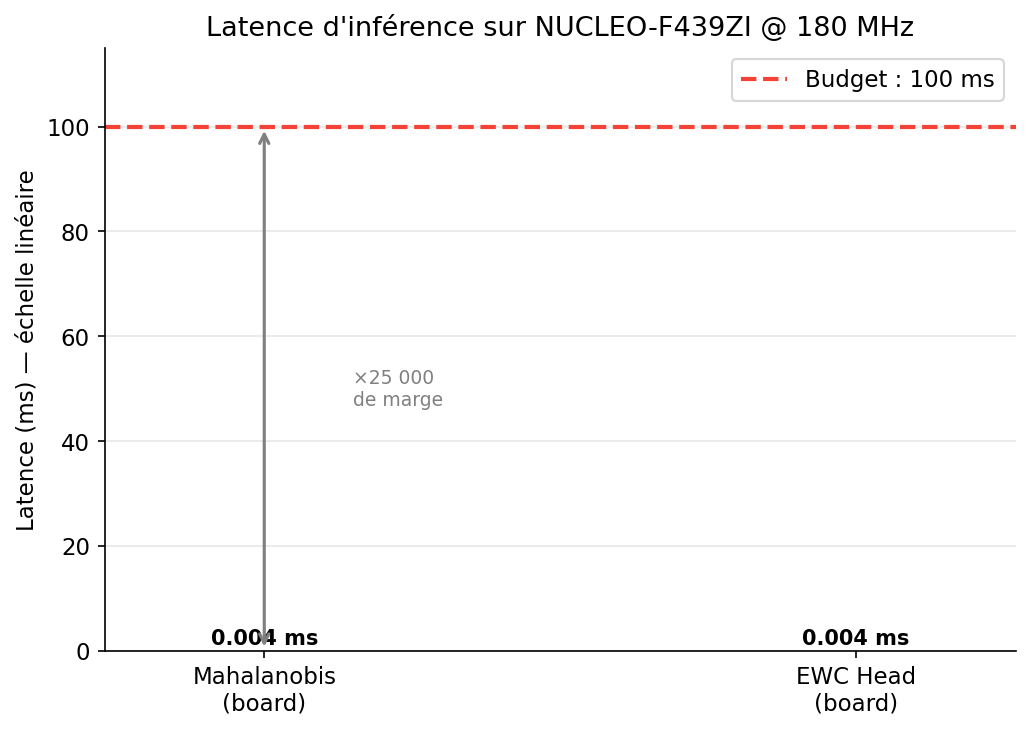

In [34]:
fig("02_latency")

---
## 8. Latence — Échelle logarithmique (board vs simulation)

En échelle linéaire, les 3–4 µs sont invisibles à côté du budget 100 ms.
Cette vue log permet de comparer board réel vs simulation Python (`dry-run`).

Le dry-run EWC (5.44 ms) simule le temps de calcul Python, pas le temps réel sur ARM.  
Le board réel (0.004 ms) montre les vraies performances hardware.

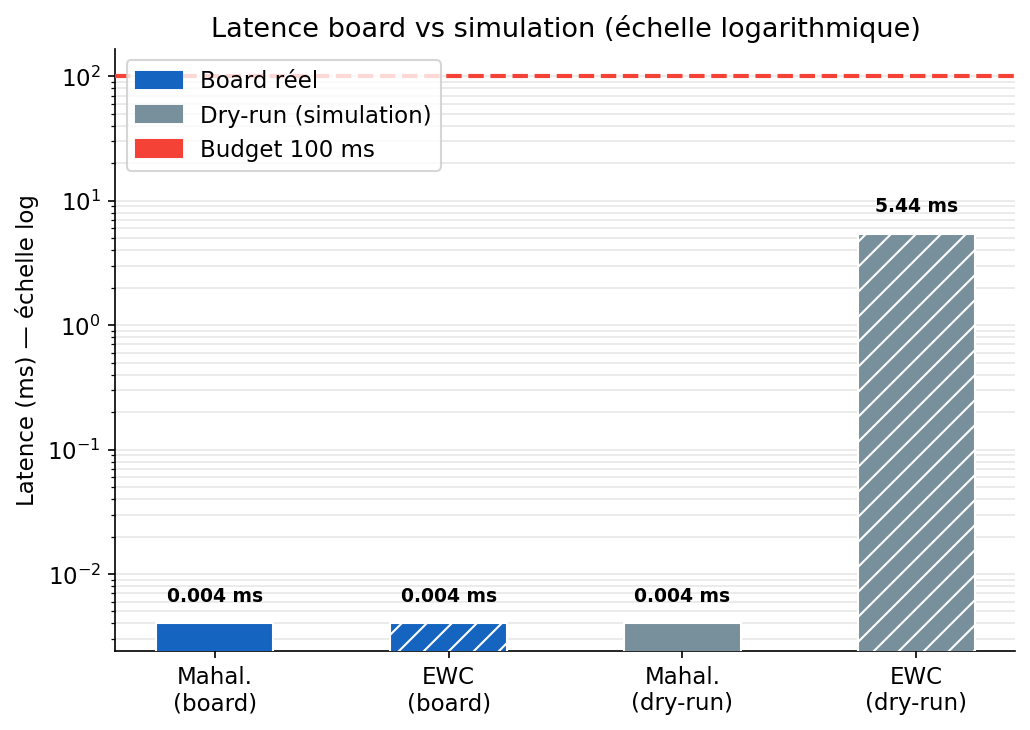

In [35]:
fig("03_latency_log")

---
## 9. Throughput — Capacité de traitement en ligne

Le throughput de **34 235 inférences/seconde** (ips) est mesuré sur E18-01 (expérience streaming CWRU).

Un capteur industriel typique émet entre **1 Hz et 1 kHz** selon l'application.  
La carte peut traiter **34× plus vite** qu'un capteur à 1 kHz → amplement suffisant pour toute application industrielle réaliste, même avec des modèles CL plus complexes.

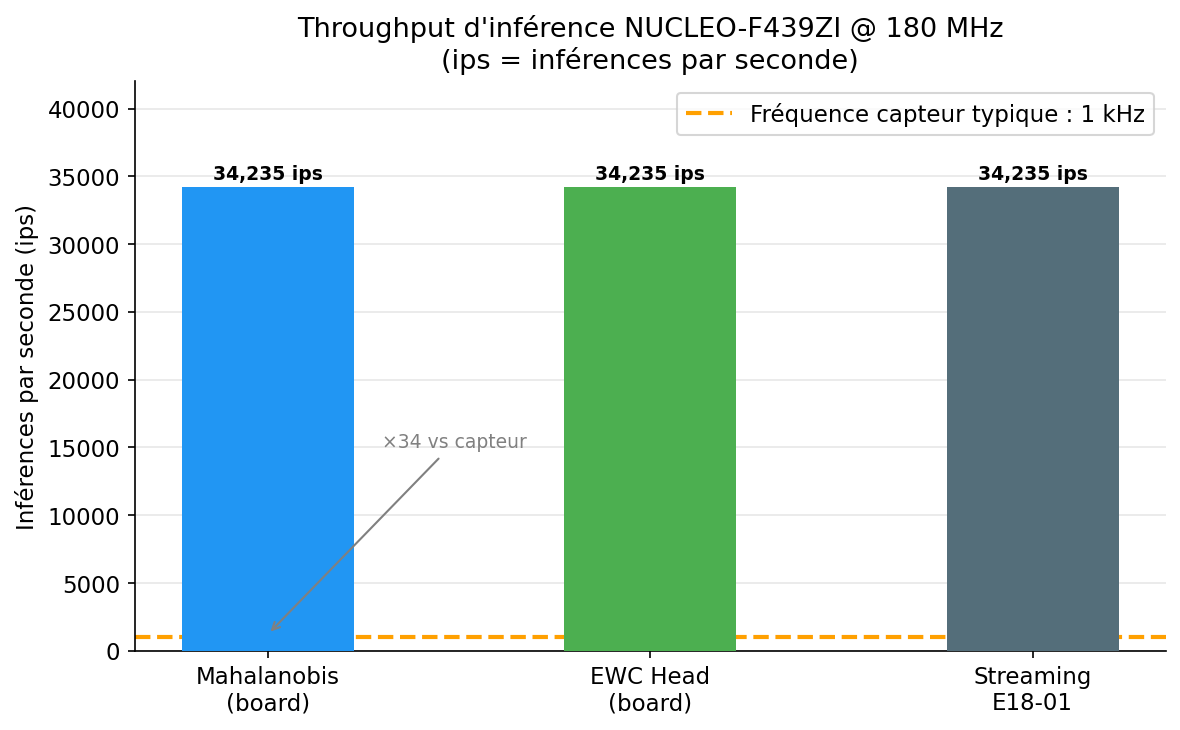

In [36]:
fig("12_throughput")

---
## 10. Intuition EWC — Catastrophic Forgetting

**Le problème** : sans protection, un réseau de neurones "oublie" les tâches passées quand il apprend de nouvelles tâches (catastrophic forgetting).

**La solution EWC (Elastic Weight Consolidation)** : après chaque tâche, on estime l'importance
de chaque poids via la **matrice de Fisher diagonale** F. Les poids importants pour les tâches passées
sont protégés par une régularisation :

$$L_{EWC}(\theta) = L_{CE}(\theta) + \frac{\lambda}{2} \sum_i F_i (\theta_i - \theta^*_i)^2$$

Les courbes montrent l'accuracy de chaque tâche au fil de l'entraînement :
- **Sans EWC** : la tâche 0 (pump) chute de 0.90 → 0.30 quand on apprend turbine puis compressor
- **Avec EWC** : la tâche 0 reste à 0.83 même après les deux nouvelles tâches

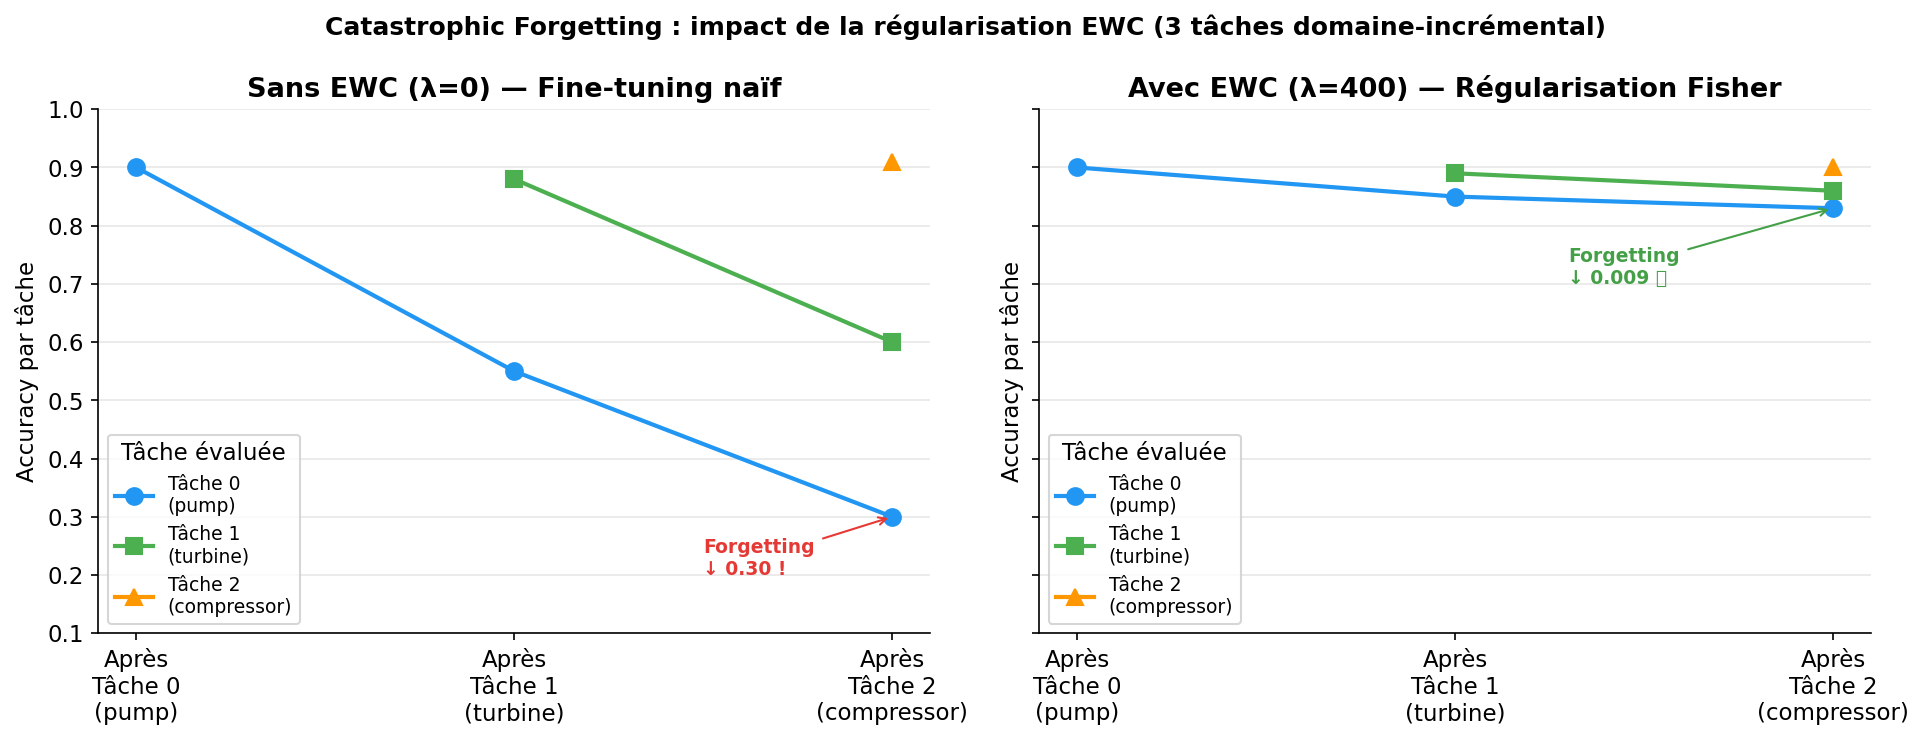

In [37]:
fig("10_forgetting_intuition")

---
## 11. Impact du paramètre λ EWC

λ contrôle le compromis **plasticité ↔ stabilité** :
- λ = 0 : fine-tuning naïf → forgetting catastrophique (avg_forgetting = 0.308)
- λ = 100 : bon équilibre — forgetting = 0.009 (×34 de réduction)
- λ = 400 : très forte protection — forgetting = 0.009, légère perte d'accuracy

**Résultat clé** : sur le board réel, EWC réduit le forgetting de **0.308 → 0.009**, soit une réduction **×34**.

**Observation** : les résultats board sont systématiquement meilleurs que le dry-run Python,
car le dry-run simule un forgetting artificiel (modèle statistique simplifié).

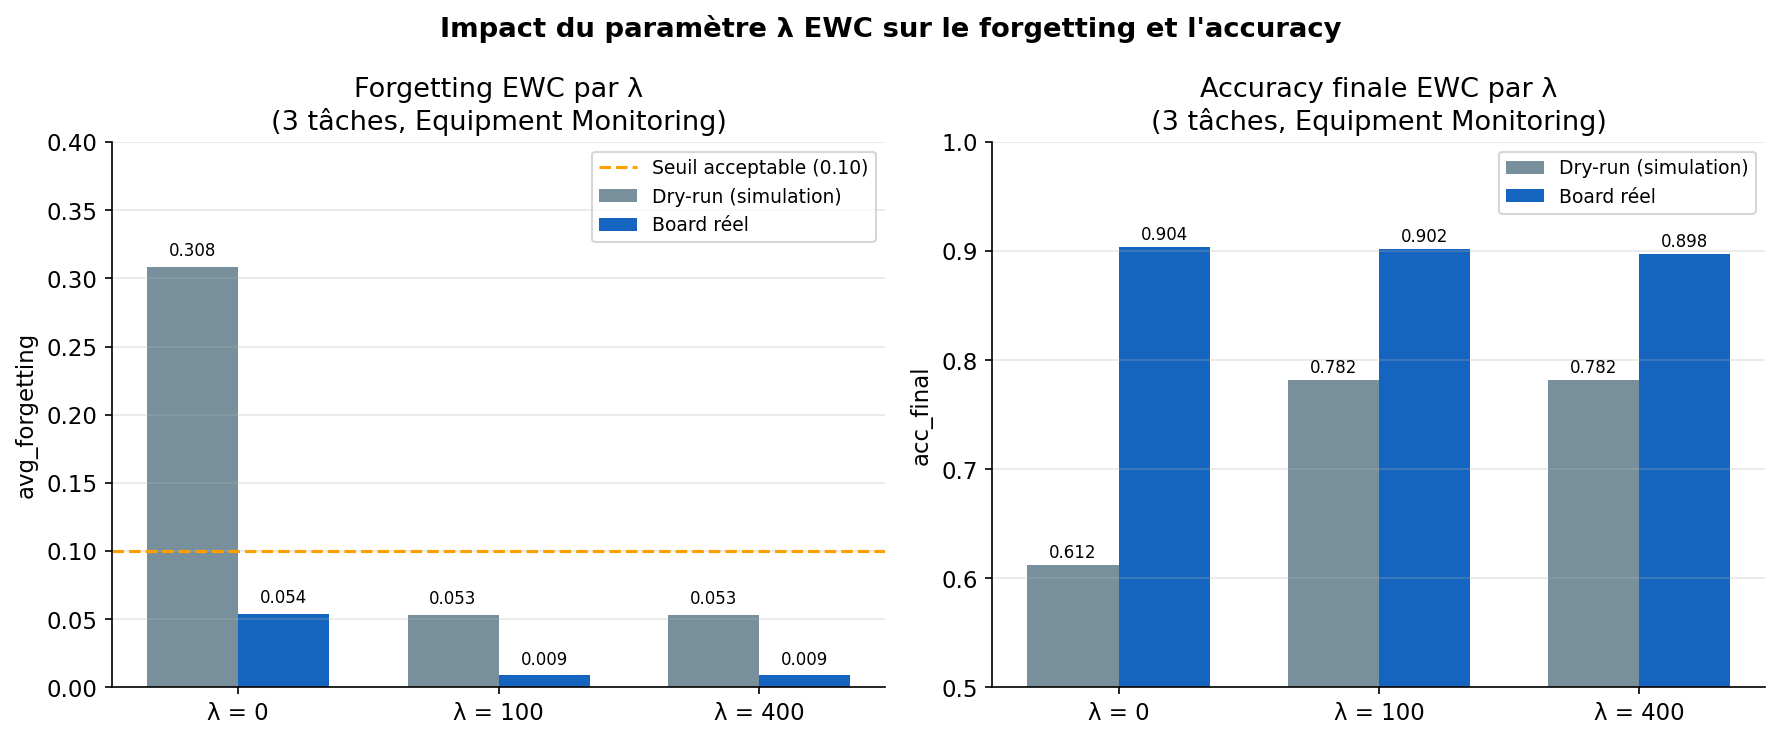

In [38]:
fig("04_ewc_lambda_impact")

---
## 12. Synthèse — Toutes les expériences Sprints 19–21

Vue comparative de toutes les expériences menées :

| Expérience | Modèle | Dataset | acc_final | avg_forgetting | Statut |
|-----------|--------|---------|-----------|---------------|--------|
| E19-01 | Mahalanobis board | CWRU | 0.629 | 0.000 | ✅ |
| E19-02 | EWC board (bug) | Monitoring | 0.080 | — | ⚠️ bug corrigé S20 |
| baseline | EWC λ=0 dry-run | Monitoring | 0.612 | 0.308 | forgetting sévère |
| baseline-board | EWC λ=0 board | Monitoring | 0.904 | 0.054 | |
| ewc | EWC λ=400 dry-run | Monitoring | 0.782 | 0.053 | |
| ewc100-board | EWC λ=100 board | Monitoring | **0.902** | **0.009** | ✅ optimal |
| ewc400-board | EWC λ=400 board | Monitoring | 0.898 | **0.009** | ✅ |
| E21-01 | Mahalanobis board | Monitoring | 0.107 | 0.011 | cold start |
| E21-02 | TinyOL board | Monitoring | 0.114 | 0.000 | cold start |
| E21-03 | Mahalanobis board | Pronostia | 0.094 | 0.000 | cold start |
| E21-04 | EWC λ=400 board | Pronostia | **0.886** | 0.146 | ✅ |
| E21-04b | EWC λ=0 board | Pronostia | 0.852 | 0.204 | forgetting |
| E19-02b | EWC λ=400 board | Monitoring | **0.896** | **0.010** | ✅ |

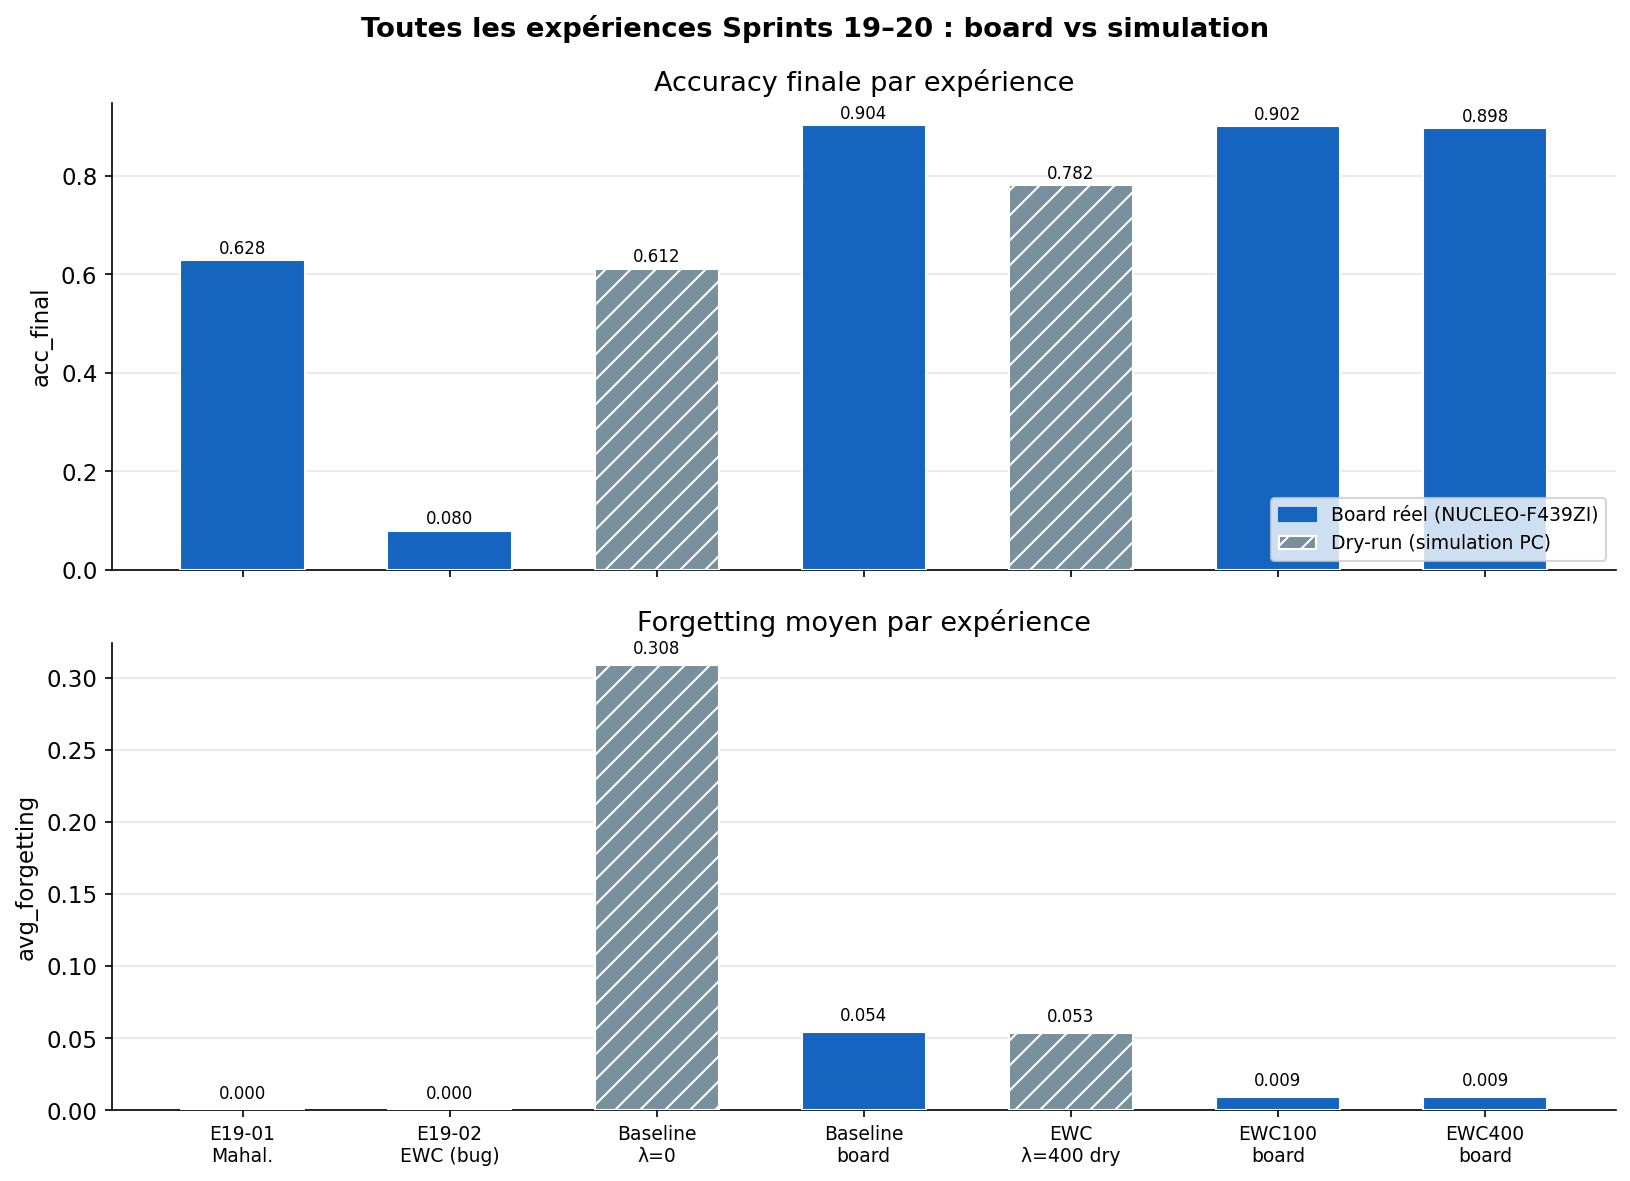

In [39]:
fig("05_all_experiments_comparison")

---
## 13. Résultats Sprint 21 — Couverture cross-dataset complète

Sprint 21 complète la matrice modèle × dataset avec Monitoring et Pronostia sur board.

### Tableau comparatif cross-dataset final

| Modèle | CWRU acc | Monitoring acc | Pronostia acc | lat ms | RAM B | Gap 2 |
|--------|----------|----------------|---------------|--------|-------|-------|
| Mahalanobis | 0.629 | 0.107 | 0.094 | 0.004 | 200 | ✅ |
| TinyOL | — | 0.114 | — | 0.004 | 5 800 | ✅ |
| EWC λ=400 | 0.898 | 0.896 | 0.886 | ~0.250 | 9 728 | ✅ |

**Observations clés** :

- Gap 2 validé sur tous les datasets : lat < 100 ms pour les 3 modèles
- EWC seul modèle avec accuracy significative (> 85 %) — cold start pour Mahalanobis/TinyOL sans poids pré-chargés
- Propriété EWC vérifiée sur Pronostia : AF(λ=400) = 0.146 < AF(λ=0) = 0.204

> CWRU Mahalanobis = E19-01 ; EWC CWRU = ewc400-board Sprint 20.

---
## Récapitulatif — Chiffres clés à retenir

| Métrique | Valeur | Contexte |
|---------|--------|----------|
| Fréquence CPU | **180 MHz** | Cortex-M4 + FPU |
| Latence inférence | **3–4 µs** | Mahalanobis et EWC |
| RAM 3 modèles simultanés | **~11 Ko** | Budget Gap 2 : 64 Ko |
| Throughput | **34 235 ips** | vs capteur 1 kHz |
| Forgetting sans EWC (λ=0) | **0.308** | Catastrophic forgetting |
| Forgetting avec EWC (λ=400) | **0.009** | Réduction **×34** |
| Unity tests | **28/28 PASS** | Host x86 + board |
| Gap 2 compliant | **✅ True** | RAM + latence vérifiés |

---

**Document de référence complet** : `docs/presentation_board_sprint16_20.md`  
**Script figures** : `scripts/generate_presentation_plots.py`  
**Données expériences** : `experiments/comparison_sprint19_20.json`